## Figure 3B. Host predictions

In [3]:
### Load packages
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import glob

In [122]:
# map from original id to species
seqhasher = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping = pl.concat([
    pl.read_csv('../figure_1/uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t'),
    pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t')
])
seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
uhvdb_source_meta = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')
genomovar_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/genomovars_cluster/hq_hc_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/species_cluster/hq_hc_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('../figure_1/uhvdb_human_metag_results/2026-03-26-2_outputs/aaicluster/hq_hc_species_aai_clusters.tsv.gz', separator='\t')

combined = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .join(genomovar_info[['uhvdb_id', 'votu_rep']], left_on='new_id', right_on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep']], left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .join(aaicluster, left_on='votu_rep', right_on='uhvdb_id', how='left')
        .filter((pl.col('seq_name') == pl.col('seqhash_rep')) & (pl.col('new_id') == pl.col('genomovar_rep')))
        .unique('seq_name')
)

In [123]:
## load uhvdb host outputs
phist_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/phisthost/new_genomovars_phisthost.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    phist_lst.append(df)

combined_phist = pl.concat(phist_lst).filter(pl.col('total_connections') > 1).filter(pl.col('consensus_taxonomy').is_not_null())

### filter to just final uhvdb genomovar reps
uhvdb_phist_df = combined_phist.filter(pl.col('uhvdb_id').is_in(set(combined['genomovar_rep'])))
print("total UHVDB genomovars w phist host:", uhvdb_phist_df.unique('uhvdb_id').shape[0])
print("total UHVDB genomovars w phist species:", uhvdb_phist_df.filter(pl.col('rank') == 'species').unique('uhvdb_id').shape[0])
print("total UHVDB genomovars w phist genus:", uhvdb_phist_df.filter(pl.col('rank') == 'genus').unique('uhvdb_id').shape[0])
print("total UHVDB genomovars w phist family:", uhvdb_phist_df.filter(pl.col('rank') == 'family').unique('uhvdb_id').shape[0])
print("Prop of genomovars w phist host:", uhvdb_phist_df.unique('uhvdb_id').shape[0] / 508382)

total UHVDB genomovars w phist host: 279187
total UHVDB genomovars w phist species: 154512
total UHVDB genomovars w phist genus: 241637
total UHVDB genomovars w phist family: 279187
Prop of genomovars w phist host: 0.5491677518086793


In [124]:
## load uhvdb host outputs
crisprhost_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/crisprhost/new_genomovars_crisprhost.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    crisprhost_lst.append(df)
combined_crisprhost = pl.concat(crisprhost_lst).filter(pl.col('total_connections') > 1).filter(pl.col('top_taxonomy').is_not_null())

### filter to just final uhvdb genomovar reps
uhvdb_crisprhost_df = combined_crisprhost.filter(pl.col('uhvdb_id').is_in(set(combined['genomovar_rep'])))
print("total UHVDB genomovars w crispr host:", uhvdb_crisprhost_df.unique('uhvdb_id').shape[0])
print("total UHVDB genomovars w crispr species:", uhvdb_crisprhost_df.filter(pl.col('rank') == 'species').unique('uhvdb_id').shape[0])
print("total UHVDB genomovars w crispr genus:", uhvdb_crisprhost_df.filter(pl.col('rank') == 'genus').unique('uhvdb_id').shape[0])
print("total UHVDB genomovars w crispr family:", uhvdb_crisprhost_df.filter(pl.col('rank') == 'family').unique('uhvdb_id').shape[0])
print("Prop of genomovars w crispr host:", uhvdb_crisprhost_df.unique('uhvdb_id').shape[0] / 508382)

total UHVDB genomovars w crispr host: 419631
total UHVDB genomovars w crispr species: 150144
total UHVDB genomovars w crispr genus: 372074
total UHVDB genomovars w crispr family: 419631
Prop of genomovars w crispr host: 0.8254245823022845


In [125]:
# identify union between phist and crisprhost
print("Prop of genomovars with crispr or phist host:",
    len(set(uhvdb_crisprhost_df['uhvdb_id']).union(set(uhvdb_phist_df['uhvdb_id']))) / 508382
)

Prop of genomovars with crispr or phist host: 0.8887214732228914


In [126]:
### create finalized host predictions
uhvdb_combinedhost =(
    uhvdb_phist_df[['uhvdb_id', 'total_connections', 'rank', 'agreement', 'consensus_taxonomy']]
        .join(
            uhvdb_crisprhost_df[['uhvdb_id', 'total_connections', 'rank', 'agreement', 'top_taxonomy']],
            on=['uhvdb_id', 'rank'],
            how='full',
            suffix='_crispr'
        )
        .fill_null(0)
        .with_columns([
            pl.col('consensus_taxonomy').str.replace(r'^(s|g|f)__', '')
        ])
        .with_columns([
            pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy')).then(pl.col('consensus_taxonomy'))
                .when((pl.col('total_connections') * pl.col('agreement')) >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))).then(pl.col('consensus_taxonomy'))
                .otherwise(pl.col('top_taxonomy'))
                .alias('final_taxonomy'),
            pl.when(pl.col('rank').is_not_null()).then(pl.col('rank')).otherwise(pl.col('rank_crispr')).alias('final_rank'),
            pl.when(pl.col('uhvdb_id').is_not_null()).then(pl.col('uhvdb_id')).otherwise(pl.col('uhvdb_id_crispr')).alias('final_id'),
            pl.when(pl.col('consensus_taxonomy') == pl.col('top_taxonomy')).then(pl.lit('methods_agree'))
                .when((pl.col('total_connections') * pl.col('agreement')) >= (pl.col('total_connections_crispr') * pl.col('agreement_crispr'))).then(pl.lit('phist_preferred'))
                .otherwise(pl.lit('crispr_preferred'))
                .alias('final_taxonomy_source'),
        ])
)

In [127]:
### Count number of host assignments at each rank
print(uhvdb_combinedhost.filter(pl.col('final_rank') == 'species').height/508382)
print(uhvdb_combinedhost.filter(pl.col('final_rank') == 'genus').height/508382)
print(uhvdb_combinedhost.filter(pl.col('final_rank') == 'family').height/508382)

0.46305140622602686
0.8172358580752269
0.8887214732228914


In [128]:
### Identify top host taxa for each body site
uhvdb_combinedhost_w_meta = (
    uhvdb_combinedhost
        .filter(pl.col('final_rank') == 'family')
        .join(combined[['genomovar_rep', 'body_site']].unique('genomovar_rep'), left_on='final_id', right_on='genomovar_rep', how='full', coalesce=True)
        .unique(['final_id'])
)

In [155]:
## load uhvdb taxonomy outputs
df_lst = []

for file in glob.glob('../figure_1/*_results/*_outputs/taxonomy/new_genomovars_ictv_taxonomy.tsv.gz'):
    df = pl.read_csv(file, separator='\t')
    df_lst.append(df)

combined_df = pl.concat(df_lst)

### identify eukaryotic viruses
euk_viruses = set(
    combined_df
        .filter(
            (pl.col('Class') == 'Papovaviricetes') |
            (pl.col('Class') == 'Cardeaviricetes') |
            (pl.col('Class') == 'Pokkesviricetes') |
            (pl.col('Class') == 'Arfiviricetes') |
            (pl.col('Class') == 'Repensiviricetes') |
            (pl.col('Class') == 'Quintoviricetes') |
            (pl.col('Class') == 'Megaviricetes') |
            (pl.col('Class') == 'Naldaviricetes') |
            (pl.col('Class') == 'Herviviricetes')
        )
        ['uhvdb_id']
)

uhvdb_combinedhost_w_meta = (
    uhvdb_combinedhost_w_meta
        .with_columns([
            pl.when(pl.col('final_id').is_in(euk_viruses))
                .then(pl.lit('Eukaryote'))
                .otherwise(pl.col('final_taxonomy'))
                .alias('final_taxonomy')
        ])
)

In [156]:
### Get top 3 host families within each body site
top_3_families_by_site = (
    uhvdb_combinedhost_w_meta
        .filter((pl.col('body_site') != 'Other') & pl.col('final_taxonomy').is_not_null())
        .group_by(['body_site', 'final_taxonomy'])
        .len()
        .sort(['body_site', 'len'], descending=[False, True])
        .with_columns(
            pl.col('len').rank(method='dense', descending=True).over('body_site').alias('rank_within_site')
        )
        .filter(pl.col('rank_within_site') <= 3)
        .select(['body_site', 'final_taxonomy', 'len'])
)

# Use the union of top 3 families across all body sites
top_families_any_site = top_3_families_by_site['final_taxonomy'].unique()

# Classify families as top-in-any-site or "Other"
host_family_classified = (
    uhvdb_combinedhost_w_meta
        .filter(pl.col('body_site') != 'Other')
        .with_columns([
            pl.when(pl.col('final_taxonomy').is_in(top_families_any_site))
                .then(pl.col('final_taxonomy'))
                .when(pl.col('final_taxonomy').is_null())
                .then(pl.lit('No host prediction'))
                .otherwise(pl.lit('Other'))
                .alias('family_classified')
        ])
)

uhvdb_host_annotations = (
    host_family_classified
        .group_by(['body_site', 'family_classified'])
        .len()
)

/tmp/ipykernel_44439/2898899945.py:22: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .with_columns([


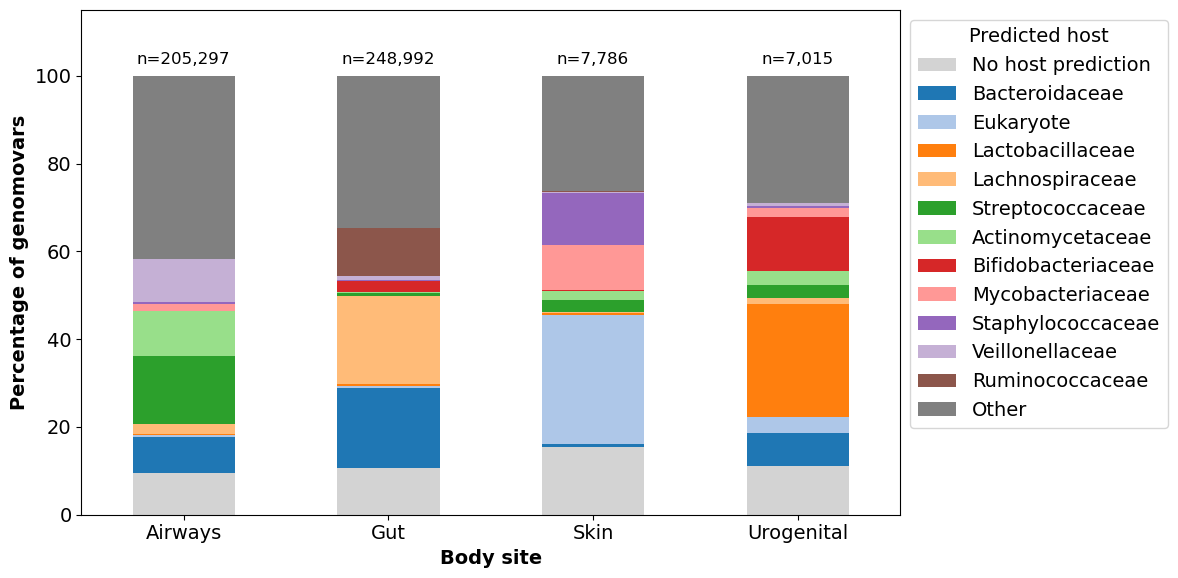

In [157]:
# Create stacked bar chart showing host family distribution by body site
family_by_site = (
    uhvdb_host_annotations
        .pivot(index='body_site', on='family_classified', values='len', aggregate_function='sum')
        .fill_null(0)
)

# Convert to pandas for easier manipulation
family_by_site_pd = family_by_site.to_pandas().set_index('body_site')
family_by_site_pd = family_by_site_pd.sort_index()  # Alphabetical x-axis order

# Calculate total counts per body site
totals = family_by_site_pd.sum(axis=1)

# Calculate proportions (normalize to 100%)
family_proportions = family_by_site_pd.div(totals, axis=0) * 100


# Order families by average abundance (greatest to least, excluding Other)
family_avg = family_proportions.mean().sort_values(ascending=False)
if 'Other' in family_avg.index:
    family_avg_no_other = family_avg.drop('Other')
    # Order: highest abundance at bottom (first), lowest at top, Other at very top
    ordered_cols = family_avg_no_other.sort_values(ascending=False).index.tolist() + ['Other']
else:
    ordered_cols = family_avg.sort_values(ascending=False).index.tolist()

family_proportions = family_proportions[ordered_cols]

# Create custom color palette - use default colors for families, light grey for No family hit, grey for Other
plt.rcParams.update({'font.size': 14})
special_labels = {'No family hit', 'Other'}
n_families = len([c for c in family_proportions.columns if c not in special_labels])
base_colors = plt.cm.tab20.colors[:n_families]
base_color_iter = iter(base_colors)
colors = []
for col in family_proportions.columns:
    if col == 'No host prediction':
        colors.append('#D3D3D3')  # Light grey
    elif col == 'Other':
        colors.append('#808080')  # Grey
    else:
        colors.append(next(base_color_iter))

# Create stacked bar chart with proportions
ax = family_proportions.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)
# make x-axis tick labels horizontal
plt.xticks(rotation=0)
plt.xlabel('Body site', fontdict={'fontweight': 'bold'})
plt.ylabel('Percentage of genomovars', fontdict={'fontweight': 'bold'})
plt.legend(title='Predicted host', bbox_to_anchor=(1.0, 1), loc='upper left')

# Add total counts above each bar
for i, (idx, total) in enumerate(totals.items()):
    ax.text(i, 102, f'n={int(total):,}', ha='center', va='bottom', fontsize=12)

plt.ylim(0, 115)  # Make room for the count labels
plt.tight_layout()
plt.show()